# CivicFix dataset playground

CivicFix is a Gainesville-area nonemergency issue reporter. This notebook inspects **CivicFix Commons Curated Collection v1**, an agent-curated collection of real Wikimedia Commons photographs. It is an initial evaluation collection, not an official benchmark. Individual authors, license versions, source revisions, actual acquisition dates and transformations are preserved in `data/labels.csv`, `docs/source_records.json`, and [DATA_SOURCES](docs/DATA_SOURCES.md).

Approved JPEGs are stored in this private GitHub repository. The config pins the dataset commit before the notebook commit. Image licenses apply individually; source attribution and share-alike notices accompany the files. This milestone performs no training, hosted-model calls, routing validation or accuracy measurement; it does not demonstrate the planned 85% classification target.

## Environment
CPU inspection with a dedicated Python 3.12 environment. These are the versions actually used by this kernel.

In [1]:
import sys, platform, json, tempfile
from pathlib import Path
from importlib.metadata import version
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown
from scripts.dataset_tools import (CATEGORIES, REQUIRED, OPTIONAL, retrieve_dataset,
    inspect_images, image_path, near_duplicate_pairs)

ROOT = Path.cwd()
assert (ROOT / 'data/dataset_config.json').is_file(), 'Run from the repository root'
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
pd.set_option('display.max_colwidth', 65)
print('Python:', platform.python_version(), '| Platform:', platform.system(), platform.machine())
display(pd.DataFrame({'package': ['pandas', 'Pillow', 'matplotlib', 'numpy', 'nbclient', 'nbformat', 'ipykernel', 'requests'],
                     'version': [version(p) for p in ['pandas', 'Pillow', 'matplotlib', 'numpy', 'nbclient', 'nbformat', 'ipykernel', 'requests']]}))

Python: 3.12.15 | Platform: Darwin arm64


,package,version
0,pandas,3.0.6
1,Pillow,12.3.0
2,matplotlib,3.11.2
3,numpy,2.5.3
4,nbclient,0.11.0
5,nbformat,5.11.1
6,ipykernel,7.4.0
7,requests,2.34.2


## Retrieval
The default mode retrieves the pinned dataset through the GitHub API. Private access uses `gh auth login` or `GITHUB_TOKEN`; credentials stay in memory. `CIVICFIX_DATA_MODE=local` copies tracked data from a clone and is explicitly reported as local. Every run starts in a new empty ignored directory, validates the manifest SHA-256 and every image SHA-256, and fails on missing, changed or unreadable data.

In [2]:
config = json.loads((ROOT / 'data/dataset_config.json').read_text())
cache_parent = ROOT / '.cache'
cache_parent.mkdir(exist_ok=True)
DATA = Path(tempfile.mkdtemp(prefix='inspection-', dir=cache_parent))
assert not any(DATA.iterdir()), 'Retrieval directory must start empty'
df, retrieval = retrieve_dataset(ROOT / 'data/dataset_config.json', DATA)
print(json.dumps(retrieval, indent=2))
print('Acquisition dates (UTC):', df.retrieved_at.min(), 'to', df.retrieved_at.max())

{
  "mode": "github",
  "dataset_name": "CivicFix Commons Curated Collection",
  "dataset_version": "v1",
  "dataset_commit": "8394bf6d0d84c9dbf33e69258f0cd15ee4795ca4",
  "validated_images": 43,
  "manifest_sha256": "98f8e250316df8c1517b381445d05dbc8a98813020930438a506e72e75dd28f9"
}
Acquisition dates (UTC): 2026-10-05T00:41:47.056961+00:00 to 2026-10-05T00:56:29.399237+00:00


## Basic information
Manifest columns describe labels and provenance. Derived width, height, byte size, file format and color mode describe image metadata; no learned image features are extracted.

In [3]:
images = inspect_images(df, DATA)
counts = df.issue_type.value_counts().reindex(CATEGORIES, fill_value=0).astype(int)
total_bytes = int(images['bytes'].sum())
print('Images:', len(images), '| Manifest rows:', len(df), '| Image bytes:', total_bytes,
      '| MiB:', round(total_bytes / 2**20, 3), '| Manifest fields:', len(df.columns))
print('Fields:', ', '.join(df.columns))
display(df.dtypes.rename('dtype').to_frame())
display(df.head(5))
display(images[['width', 'height', 'bytes']].describe().round(1))
display(images.groupby(['format', 'mode']).size().rename('images').to_frame())

Images: 43 | Manifest rows: 43 | Image bytes: 13020816 | MiB: 12.418 | Manifest fields: 21
Fields: image_id, filename, issue_type, source_name, source_url, download_url, source_version, author, license, license_url, retrieved_at, label_basis, review_status, sha256, notes, source_title, location, capture_date, lighting, weather, scene_id


,dtype
image_id,str
filename,str
issue_type,str
source_name,str
source_url,str
download_url,str
source_version,str
author,str
license,str
license_url,str


,image_id,filename,issue_type,source_name,source_url,download_url,source_version,author,license,license_url,...,label_basis,review_status,sha256,notes,source_title,location,capture_date,lighting,weather,scene_id
0,commons-04258228ae,images/commons-04258228ae.jpg,damaged_sign,Wikimedia Commons curated subset,https://commons.wikimedia.org/wiki/File:Damaged_road_sign_alo...,https://upload.wikimedia.org/wikipedia/commons/d/d4/Damaged_r...,Commons page revision 945805704; file upload 2023-01-24T15:59...,Kenneth Allen,CC BY-SA 2.0,https://creativecommons.org/licenses/by-sa/2.0,...,Source caption: Damaged road sign along Seein Road | Agent vi...,agent_reviewed,6e993aeb19313244070ac572c3988c13b93b7e2da8452f8cf45429d5a0696f54,Commons thumbnail where available; EXIF orientation applied; ...,Damaged road sign along Seein Road - geograph.org.uk - 432520...,"Seein Road, United Kingdom",2015-01-27,daylight,,commons-04258228ae
1,commons-0a68e3b438,images/commons-0a68e3b438.jpg,pothole,Wikimedia Commons curated subset,https://commons.wikimedia.org/wiki/File:A_photo_of_a_pothole_...,https://thumb.wikimedia.org/wikipedia/commons/thumb/8/82/A_ph...,Commons page revision 1003535190; file upload 2022-10-06T06:0...,Thomas Booker (CoderThomasB),CC BY-SA 4.0,https://creativecommons.org/licenses/by-sa/4.0,...,Source caption: A photo of a pothole. | Agent visual review: ...,agent_reviewed,7e3412a29abf122b0d8a3558cf34e8295ddd73d4b1fc2ba247c9edac6f0234bb,Commons thumbnail where available; EXIF orientation applied; ...,A photo of a pothole 2021-07-11.jpg,,,low_light,,commons-0a68e3b438
2,commons-0f02ab33ca,images/commons-0f02ab33ca.jpg,illegal_dumping,Wikimedia Commons curated subset,"https://commons.wikimedia.org/wiki/File:Fly-tipping,_Johnston...",https://upload.wikimedia.org/wikipedia/commons/thumb/2/2d/Fly...,Commons page revision 1255492093; file upload 2011-03-04T03:0...,wfmillar,CC BY-SA 2.0,https://creativecommons.org/licenses/by-sa/2.0,...,"Source caption: Fly-tipping, Johnstone Thrown over the hedge ...",agent_reviewed,5da0ae0b303a49530b31fed46553e2bd37b4249f6584d4f25d1acd0e1c630e1c,Commons cached thumbnail (330 px for small originals) where a...,"Fly-tipping, Johnstone - geograph.org.uk - 1597453.jpg","Johnstone, United Kingdom",2009-11-27,daylight,,commons-0f02ab33ca
3,commons-1b000da556,images/commons-1b000da556.jpg,leaking_hydrant,Wikimedia Commons curated subset,https://commons.wikimedia.org/wiki/File:Leaking_Fire_Hydrant_...,https://upload.wikimedia.org/wikipedia/commons/thumb/8/86/Lea...,Commons page revision 975319840; file upload 2011-02-26T06:57...,PAUL FARMER,CC BY-SA 2.0,https://creativecommons.org/licenses/by-sa/2.0,...,Source caption: Leaking Fire Hydrant. In Balniel Gate | Agent...,agent_reviewed,8f5d90ffbb70e2ec3f80d4db6ae19586b102812e7d9cddd3921c8cf9116812c0,Commons cached thumbnail (330 px for small originals) where a...,Leaking Fire Hydrant - geograph.org.uk - 1219371.jpg,"Balniel Gate, United Kingdom",2009-03-24,daylight,,commons-1b000da556
4,commons-1be7ba9610,images/commons-1be7ba9610.jpg,damaged_sign,Wikimedia Commons curated subset,https://commons.wikimedia.org/wiki/File:A_damaged_road_sign_a...,https://upload.wikimedia.org/wikipedia/commons/d/db/A_damaged...,Commons page revision 945626135; file upload 2023-02-24T19:33...,Kenneth Allen,CC BY-SA 2.0,https://creativecommons.org/licenses/by-sa/2.0,...,"Source caption: A damaged road sign at Tamlaght, Newtownsavil...",agent_reviewed,f48711a0ed3b2e38475185ac9914e6efe8b1bfba47a25c065090ac2745b29a0c,Commons thumbnail where available; EXIF orientation applied; ...,"A damaged road sign at Tamlaght, Newtownsaville - geograph.or...","Tamlaght, Newtownsaville, United Kingdom",2015-05-01,daylight,,commons-1be7ba9610


,width,height,bytes
count,43.0,43.0,43.0
mean,894.3,777.0,302809.7
std,394.3,362.2,246936.7
min,330.0,160.0,22118.0
25%,551.0,480.0,66108.0
50%,960.0,853.0,246315.0
75%,1280.0,960.0,505764.0
max,1280.0,1280.0,911438.0


,,images
format,mode,
JPEG,RGB,43


## Real examples
Two deterministic examples per available category. Empty categories are shown explicitly if present. Captions identify the matching attribution records below and in [DATA_SOURCES](docs/DATA_SOURCES.md).

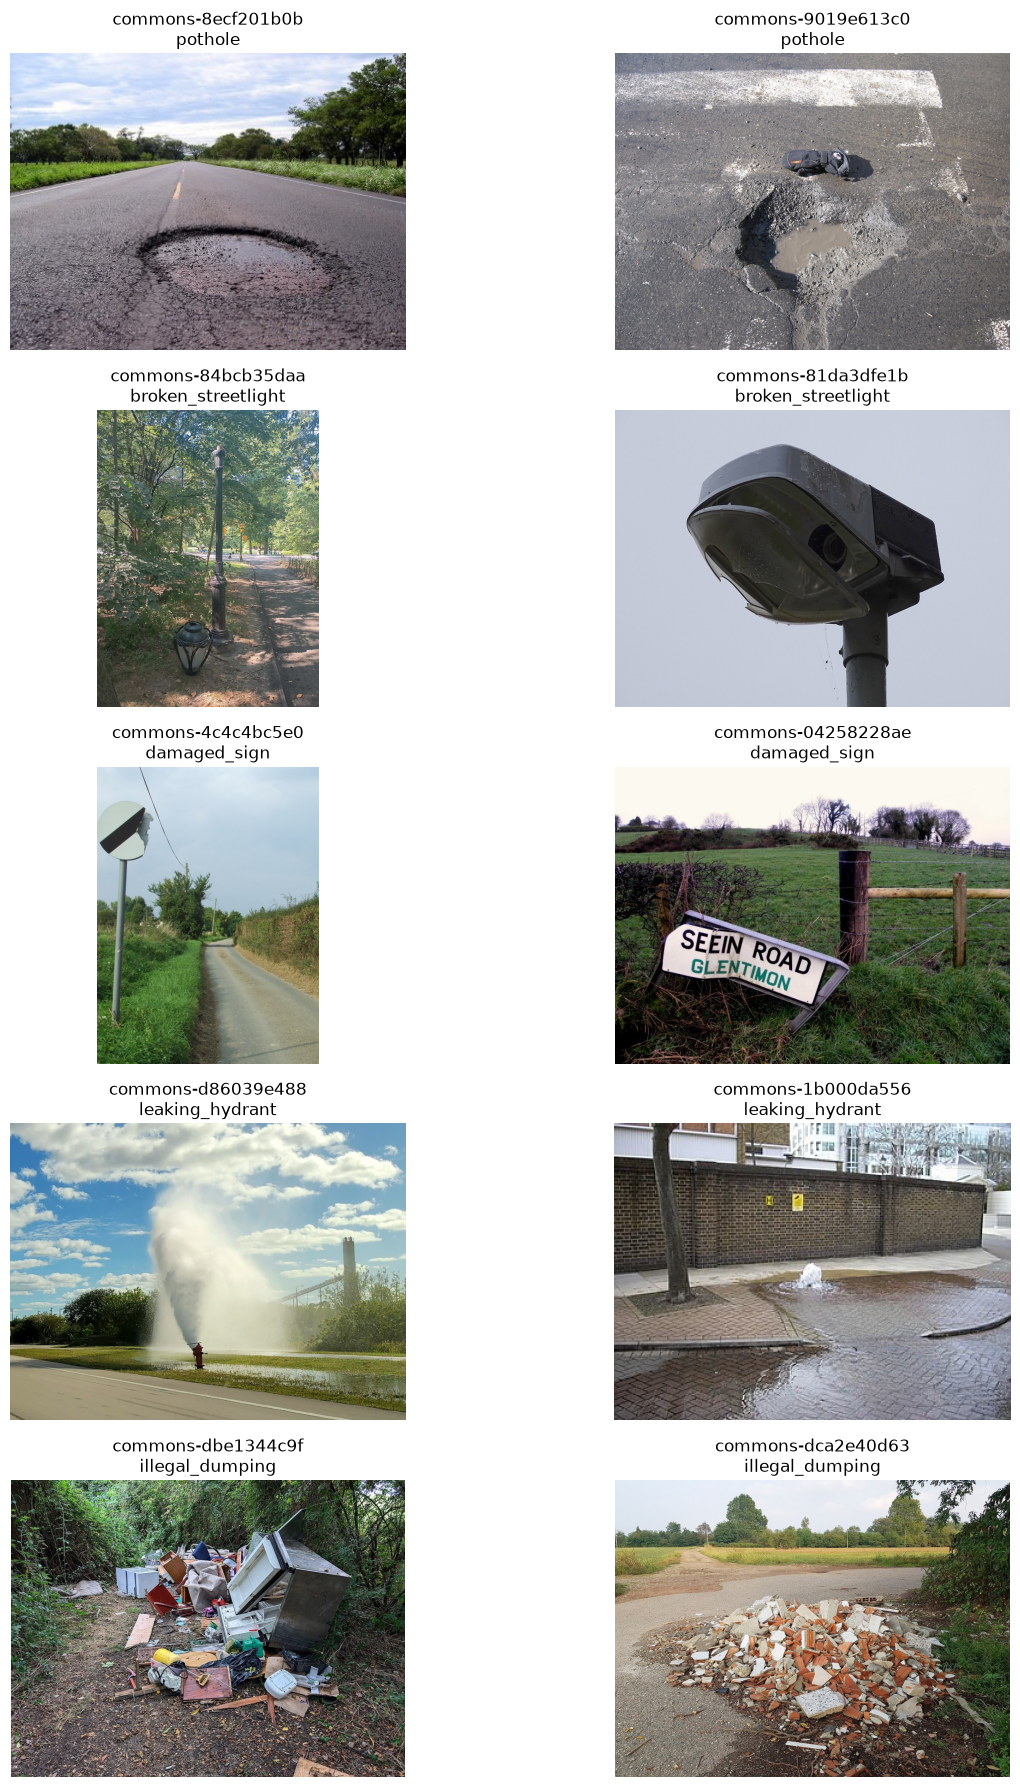

,image_id,author,license,source_url,notes
commons-8ecf201b0b,commons-8ecf201b0b,Uncl3dad,Public domain,https://commons.wikimedia.org/wiki/File:Pothole_Big.jpg,Commons thumbnail where available; EXIF orientation applied; ...
commons-9019e613c0,commons-9019e613c0,Miguel Tremblay,Public domain,"https://commons.wikimedia.org/wiki/File:Pothole_in_Villeray,_...",Commons thumbnail where available; EXIF orientation applied; ...
commons-84bcb35daa,commons-84bcb35daa,Jay Dobkin,CC BY-SA 4.0,https://commons.wikimedia.org/wiki/File:Decapitated_lamppost_...,Commons thumbnail where available; EXIF orientation applied; ...
commons-81da3dfe1b,commons-81da3dfe1b,ŠJů,CC BY 4.0,"https://commons.wikimedia.org/wiki/File:Chalupkova,_rozbit%C3...",Commons thumbnail where available; EXIF orientation applied; ...
commons-4c4c4bc5e0,commons-4c4c4bc5e0,Keith Evans,CC BY-SA 2.0,https://commons.wikimedia.org/wiki/File:Broken_road_sign_-_ge...,Commons thumbnail where available; EXIF orientation applied; ...
commons-04258228ae,commons-04258228ae,Kenneth Allen,CC BY-SA 2.0,https://commons.wikimedia.org/wiki/File:Damaged_road_sign_alo...,Commons thumbnail where available; EXIF orientation applied; ...
commons-d86039e488,commons-d86039e488,Kiran891,CC BY-SA 4.0,https://commons.wikimedia.org/wiki/File:Broken_fire_hydrant_l...,Commons thumbnail where available; EXIF orientation applied; ...
commons-1b000da556,commons-1b000da556,PAUL FARMER,CC BY-SA 2.0,https://commons.wikimedia.org/wiki/File:Leaking_Fire_Hydrant_...,Commons cached thumbnail (330 px for small originals) where a...
commons-dbe1344c9f,commons-dbe1344c9f,The wub,CC BY-SA 4.0,https://commons.wikimedia.org/wiki/File:Fly_tipping_near_High...,Commons thumbnail where available; EXIF orientation applied; ...
commons-dca2e40d63,commons-dca2e40d63,Mænsard vokser,CC BY-SA 4.0,https://commons.wikimedia.org/wiki/File:Fly-tipping_construct...,Commons thumbnail where available; EXIF orientation applied; ...


In [4]:
fig, axes = plt.subplots(len(CATEGORIES), 2, figsize=(14, 18))
example_rows = []
example_ids = {
    'pothole': ['commons-8ecf201b0b', 'commons-9019e613c0'],
    'broken_streetlight': ['commons-84bcb35daa', 'commons-81da3dfe1b'],
    'damaged_sign': ['commons-4c4c4bc5e0', 'commons-04258228ae'],
    'leaking_hydrant': ['commons-d86039e488', 'commons-1b000da556'],
    'illegal_dumping': ['commons-dbe1344c9f', 'commons-dca2e40d63'],
}
for i, category in enumerate(CATEGORIES):
    available = df[df.issue_type.eq(category)]
    preferred = [image_id for image_id in example_ids[category] if image_id in available.image_id.values]
    subset = available.set_index('image_id', drop=False).reindex(preferred) if preferred else available.sort_values('image_id').head(2)
    for j in range(2):
        ax = axes[i, j]
        ax.axis('off')
        if j < len(subset):
            row = subset.iloc[j]
            with Image.open(image_path(DATA, row.filename)) as im:
                ax.imshow(im)
            ax.set_title(f'{row.image_id}\n{row.issue_type}', fontsize=12)
            example_rows.append(row)
        else:
            ax.text(.5, .5, f'{category}\nNo example available', ha='center', va='center', transform=ax.transAxes)
fig.tight_layout()
fig.savefig(cache_parent / 'example_grid.png', dpi=110, bbox_inches='tight')
plt.show()
display(pd.DataFrame(example_rows)[['image_id', 'author', 'license', 'source_url', 'notes']])

## Quality checks
Missing required values are errors. Empty optional values mean genuinely unrecorded conditions, not inferred Gainesville locations. Hashes detect byte-identical duplicates. A simple 64-bit average hash screens possible near duplicates; it is not a learned representation and cannot prove that different views of the same issue are independent.

,missing
image_id,0
filename,0
issue_type,0
source_name,0
source_url,0
download_url,0
source_version,0
author,0
license,0
license_url,0


,result
required_missing,0
duplicate_ids,0
duplicate_filenames,0
unsupported_labels,0
missing_files,0
decode_successes,43
hash_mismatches,0
exact_duplicate_images,0
inconsistent_hash_labels,0
images_with_exif,0


,images
issue_type,
pothole,10
broken_streetlight,10
damaged_sign,10
leaking_hydrant,3
illegal_dumping,10


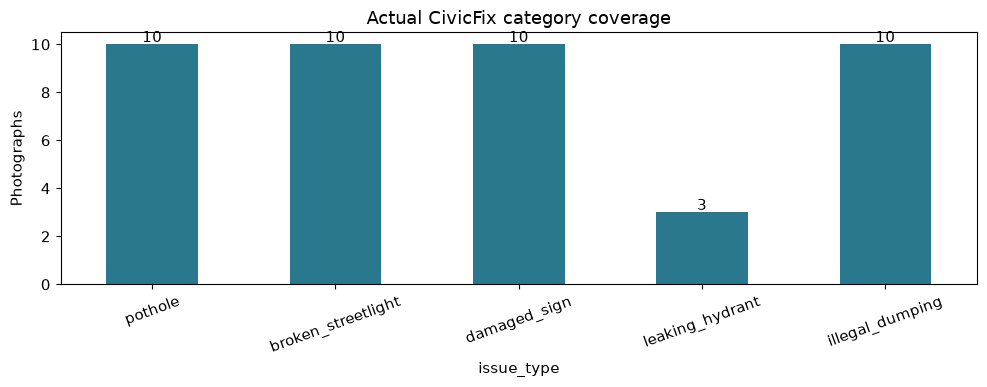

Possible near-duplicate pairs (average-hash distance <= 6): 3


,left_id,right_id,distance,same_label
0,commons-5000667ac9,commons-bb9ea4bd37,5,False
1,commons-bb9ea4bd37,commons-ddf392a527,6,False
2,commons-bb9ea4bd37,commons-f5eb1a435d,6,False


Resolution range: 330 to 1280 wide; 160 to 1280 high


In [5]:
missing = df.apply(lambda column: column.str.strip().eq('').sum()).rename('missing')
display(missing.to_frame())
required_missing = int(missing.reindex(REQUIRED).sum())
optional_missing = missing.reindex(OPTIONAL)
exact_duplicates = int(df.sha256.duplicated().sum())
inconsistent_hash_labels = int((df.groupby('sha256').issue_type.nunique() > 1).sum())
checks = {
    'required_missing': required_missing,
    'duplicate_ids': int(df.image_id.duplicated().sum()),
    'duplicate_filenames': int(df.filename.duplicated().sum()),
    'unsupported_labels': int((~df.issue_type.isin(CATEGORIES)).sum()),
    'missing_files': int(sum(not image_path(DATA, f).is_file() for f in df.filename)),
    'decode_successes': len(images),
    'hash_mismatches': int((~images.hash_matches).sum()),
    'exact_duplicate_images': exact_duplicates,
    'inconsistent_hash_labels': inconsistent_hash_labels,
    'images_with_exif': int(images.exif_fields.gt(0).sum()),
    'images_with_gps': int(images.has_gps.sum()),
    'images_without_agent_review': int(df.review_status.ne('agent_reviewed').sum()),
}
display(pd.Series(checks, name='result').to_frame())
assert required_missing == 0 and len(df) == len(images)
assert all(checks[k] == 0 for k in checks if k != 'decode_successes'), 'Quality gate failed'
display(counts.rename('images').to_frame())
fig, ax = plt.subplots(figsize=(10, 4))
counts.plot.bar(ax=ax, color='#2a788e', rot=20)
ax.set_ylabel('Photographs'); ax.set_title('Actual CivicFix category coverage')
for i, count in enumerate(counts): ax.text(i, count + .1, str(count), ha='center')
fig.tight_layout(); plt.show()
pairs = near_duplicate_pairs(df, DATA)
print('Possible near-duplicate pairs (average-hash distance <= 6):', len(pairs))
display(pairs)
print('Resolution range:', images.width.min(), 'to', images.width.max(), 'wide;',
      images.height.min(), 'to', images.height.max(), 'high')

### Agent visual review and ambiguity
Each included candidate was compared with its caption and inspected by the agent for defect evidence and privacy. This is not independent human validation. Alternate views of the same object, ambiguous scenes, a hydrant test, unreadable data and privacy risks were excluded or recorded in [candidate_review.csv](docs/candidate_review.csv). A dumping photograph needs source context to establish unauthorized disposal. Damaged streetlights show structural damage; the collection does not establish electrical failure from daylight appearance.

The curation review considered scene similarity as well as image hashes. Per-image evidence is in `label_basis` and the source records. Any low-distance pairs printed above need the documented visual comparison; an empty screening table would not prove near duplicates are absent.

This run screened three cross-category near-duplicate pairs. Agent visual comparison found distinct subjects and scenes (damaged sign versus dumping, dumping versus pothole, dumping versus another sign); the low-distance global hashes are screening false positives. See [NEAR_DUPLICATE_REVIEW](docs/NEAR_DUPLICATE_REVIEW.md). Two UK hydrant examples rely on explicit source captions because the hydrant body is not visible; they cannot substantiate photo-only hydrant-recognition performance.

## Findings and decisions
These measured results come from the retrieved files. Detailed selection decisions and remaining coverage gaps are in [DATA_QUALITY](docs/DATA_QUALITY.md).

In [6]:
print(f'Final included subset: {len(df)} photos, {total_bytes:,} image bytes ({total_bytes / 2**20:.3f} MiB).')
print('Category counts:', counts.to_dict())
print('Zero-example categories:', counts[counts.eq(0)].index.tolist())
print('Categories below the approximate 10-image target:', counts[counts.lt(10)].to_dict())
print('License counts:', df.license.value_counts().to_dict())
print('Unrecorded optional metadata:', optional_missing.to_dict())
print('Recorded lighting:', df.lighting.value_counts().to_dict())
print('No measured classification accuracy, latency, model availability test or Gainesville routing result.')
summary = {'retrieval': retrieval, 'image_count': len(df), 'image_bytes': total_bytes,
           'manifest_rows': len(df), 'manifest_fields': len(df.columns),
           'counts': counts.to_dict(), 'checks': checks, 'optional_missing': optional_missing.to_dict(),
           'near_duplicate_pairs': pairs.to_dict(orient='records'),
           'width_min': int(images.width.min()), 'width_max': int(images.width.max()),
           'height_min': int(images.height.min()), 'height_max': int(images.height.max()),
           'python': platform.python_version()}
(cache_parent / 'run_summary.json').write_text(json.dumps(summary, indent=2))

Final included subset: 43 photos, 13,020,816 image bytes (12.418 MiB).
Category counts: {'pothole': 10, 'broken_streetlight': 10, 'damaged_sign': 10, 'leaking_hydrant': 3, 'illegal_dumping': 10}
Zero-example categories: []
Categories below the approximate 10-image target: {'leaking_hydrant': 3}
License counts: {'CC BY-SA 2.0': 17, 'CC BY-SA 4.0': 15, 'CC0': 4, 'Public domain': 3, 'CC BY 4.0': 2, 'CC BY 2.0': 1, 'CC BY-SA 3.0': 1}
Unrecorded optional metadata: {'location': 6, 'capture_date': 21, 'lighting': 0, 'weather': 43, 'scene_id': 0}
Recorded lighting: {'daylight': 42, 'low_light': 1}
No measured classification accuracy, latency, model availability test or Gainesville routing result.


1607

## Reproduction summary
Install the pinned requirements and run `python scripts/execute_notebook.py` from the repository root. The executor uses a fresh kernel, stops on any cell error and saves this notebook only after success. To use a clean clone without GitHub downloads, set `CIVICFIX_DATA_MODE=local` explicitly. Detailed commands, private access prerequisites and Docker limitations are in [README](README.md).

In [7]:
print('Tested execution mode:', retrieval['mode'])
print('Python:', platform.python_version())
print('Dataset version:', retrieval['dataset_version'])
print('Pinned dataset commit:', retrieval['dataset_commit'])
print('This run used an initially empty retrieval directory and validated', retrieval['validated_images'], 'images.')
display(Markdown('Limitations: small convenience sample, agent labels, uneven categories, mostly daylight and nonlocal scenes. '
                 'Unknown conditions remain missing; this collection cannot validate Gainesville routing or the 85% target. '
                 'See [source records](docs/DATA_SOURCES.md) and [quality findings](docs/DATA_QUALITY.md).'))

Tested execution mode: github
Python: 3.12.15
Dataset version: v1
Pinned dataset commit: 8394bf6d0d84c9dbf33e69258f0cd15ee4795ca4
This run used an initially empty retrieval directory and validated 43 images.


Limitations: small convenience sample, agent labels, uneven categories, mostly daylight and nonlocal scenes. Unknown conditions remain missing; this collection cannot validate Gainesville routing or the 85% target. See [source records](docs/DATA_SOURCES.md) and [quality findings](docs/DATA_QUALITY.md).